In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

seq1 = 'ATGCAGCAGCAGCCA'
seq2 = 'ATATAT'

MATCH    =  1
MISMATCH = -1

def score_sub(a, b):
    return MATCH if a == b else MISMATCH

In [12]:
def needleman_wunsch_linear(seq1, seq2, gap=-4):
    
    n, m = len(seq1), len(seq2)
    
    dp = np.zeros((n + 1, m + 1), dtype=int)
    tb = np.full((n + 1, m + 1), '', dtype=object)  
    
    for i in range(n + 1):
        dp[i][0] = i * gap
        tb[i][0] = 'U'  
    for j in range(m + 1):
        dp[0][j] = j * gap
        tb[0][j] = 'L'  
    tb[0][0] = 'S'  
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            diag = dp[i-1][j-1] + score_sub(seq1[i-1], seq2[j-1])
            up   = dp[i-1][j]   + gap
            left = dp[i][j-1]   + gap
            
            best = max(diag, up, left)
            dp[i][j] = best
            
            if best == diag:
                tb[i][j] = 'D' 
            elif best == up:
                tb[i][j] = 'U'
            else:
                tb[i][j] = 'L'
    
    return dp, tb


def traceback(tb, seq1, seq2):

    aligned1, aligned2 = [], []
    i, j = len(seq1), len(seq2)
    
    while i > 0 or j > 0:
        if tb[i][j] == 'D':
            aligned1.append(seq1[i-1])
            aligned2.append(seq2[j-1])
            i -= 1; j -= 1
        elif tb[i][j] == 'U':
            aligned1.append(seq1[i-1])
            aligned2.append('-')
            i -= 1
        else:  # 'L'
            aligned1.append('-')
            aligned2.append(seq2[j-1])
            j -= 1
    
    aligned1 = ''.join(reversed(aligned1))
    aligned2 = ''.join(reversed(aligned2))
    return aligned1, aligned2


def print_alignment(a1, a2):
    
    mid = ''.join('|' if c1 == c2 else ' ' for c1, c2 in zip(a1, a2))
    print(f'Seq1: {a1}')
    print(f'      {mid}')
    print(f'Seq2: {a2}')



dp_lin, tb_lin = needleman_wunsch_linear(seq1, seq2, gap=-4)
score_lin = dp_lin[len(seq1)][len(seq2)]

print(f'=== Линейный штраф (Gap = -4) ===')
print(f'Score: {score_lin}\n')

a1_lin, a2_lin = traceback(tb_lin, seq1, seq2)
print_alignment(a1_lin, a2_lin)

=== Линейный штраф (Gap = -4) ===
Score: -34

Seq1: ATGCAGCAGCAGCCA
      ||     |  |    
Seq2: AT-----A-TA---T


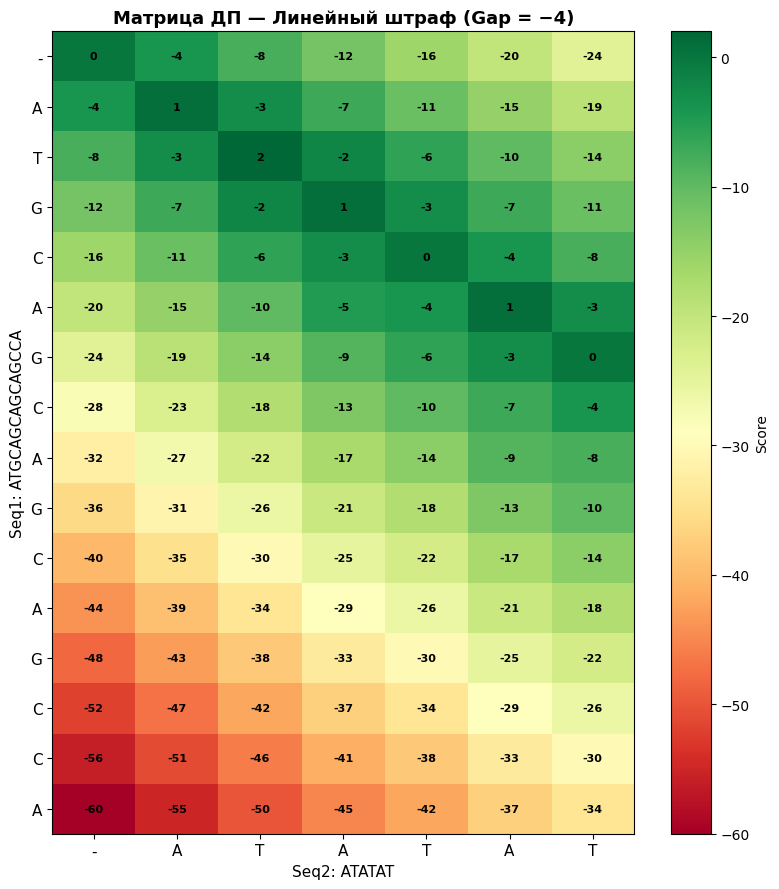

In [13]:
def plot_matrix(dp, seq1, seq2, title):
    
    n, m = len(seq1), len(seq2)
    
    fig, ax = plt.subplots(figsize=(max(8, m+2), max(6, n//2+2)))
    
    im = ax.imshow(dp, cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax, label='Score')
    
    ax.set_xticks(range(m + 1))
    ax.set_xticklabels(['-'] + list(seq2), fontsize=11)
    ax.set_yticks(range(n + 1))
    ax.set_yticklabels(['-'] + list(seq1), fontsize=11)
    
    for i in range(n + 1):
        for j in range(m + 1):
            ax.text(j, i, str(dp[i][j]), ha='center', va='center',
                    fontsize=8, color='black', fontweight='bold')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Seq2: ' + seq2, fontsize=11)
    ax.set_ylabel('Seq1: ' + seq1, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_matrix(dp_lin, seq1, seq2, 'Матрица ДП — Линейный штраф (Gap = −4)')

In [15]:
def needleman_wunsch_affine(seq1, seq2, gap_open=-10, gap_extend=-1):

    n, m = len(seq1), len(seq2)
    NEG_INF = -10**9
    
    M  = np.full((n+1, m+1), NEG_INF, dtype=float)
    Ix = np.full((n+1, m+1), NEG_INF, dtype=float)
    Iy = np.full((n+1, m+1), NEG_INF, dtype=float)
    
    tbM  = np.full((n+1, m+1), '', dtype=object)
    tbIx = np.full((n+1, m+1), '', dtype=object)
    tbIy = np.full((n+1, m+1), '', dtype=object)
    
    M[0][0] = 0
    
    for i in range(1, n+1):
        Ix[i][0] = gap_open + (i-1) * gap_extend
        tbIx[i][0] = 'Ix'
        
    for j in range(1, m+1):
        Iy[0][j] = gap_open + (j-1) * gap_extend
        tbIy[0][j] = 'Iy'
    
    for i in range(1, n+1):
        for j in range(1, m+1):
            s = score_sub(seq1[i-1], seq2[j-1])
    
            opts_M = [
                (M[i-1][j-1]  + s, 'M'),
                (Ix[i-1][j-1] + s, 'Ix'),
                (Iy[i-1][j-1] + s, 'Iy'),
            ]
            M[i][j], tbM[i][j] = max(opts_M, key=lambda x: x[0])
    
            opts_Ix = [
                (M[i-1][j]  + gap_open,   'M'),
                (Ix[i-1][j] + gap_extend, 'Ix'),
            ]
            Ix[i][j], tbIx[i][j] = max(opts_Ix, key=lambda x: x[0])
            
            opts_Iy = [
                (M[i][j-1]  + gap_open,   'M'),
                (Iy[i][j-1] + gap_extend, 'Iy'),
            ]
            Iy[i][j], tbIy[i][j] = max(opts_Iy, key=lambda x: x[0])
    
    final_scores = [(M[n][m], 'M'), (Ix[n][m], 'Ix'), (Iy[n][m], 'Iy')]
    score, start_mat = max(final_scores, key=lambda x: x[0])
    
    return int(score), M, Ix, Iy, tbM, tbIx, tbIy, start_mat


def traceback_affine(M, Ix, Iy, tbM, tbIx, tbIy, seq1, seq2, start_mat):
    aligned1, aligned2 = [], []
    i, j = len(seq1), len(seq2)
    cur = start_mat
    
    while i > 0 or j > 0:
        if cur == 'M':
            aligned1.append(seq1[i-1])
            aligned2.append(seq2[j-1])
            cur = tbM[i][j]
            i -= 1; j -= 1
        elif cur == 'Ix':
            aligned1.append(seq1[i-1])
            aligned2.append('-')
            cur = tbIx[i][j]
            i -= 1
        else: 
            aligned1.append('-')
            aligned2.append(seq2[j-1])
            cur = tbIy[i][j]
            j -= 1
    
    return ''.join(reversed(aligned1)), ''.join(reversed(aligned2))


score_aff, M_aff, Ix_aff, Iy_aff, tbM, tbIx, tbIy, sm = needleman_wunsch_affine(
    seq1, seq2, gap_open=-10, gap_extend=-1
)

print(f'Аффинный штраф (Open = -10, Extend = -1)')
print(f'Score: {score_aff}\n')

a1_aff, a2_aff = traceback_affine(M_aff, Ix_aff, Iy_aff, tbM, tbIx, tbIy, seq1, seq2, sm)
print_alignment(a1_aff, a2_aff)

Аффинный штраф (Open = -10, Extend = -1)
Score: -18

Seq1: ATGCAGCAGCAGCCA
      ||  |          
Seq2: ATATA---------T


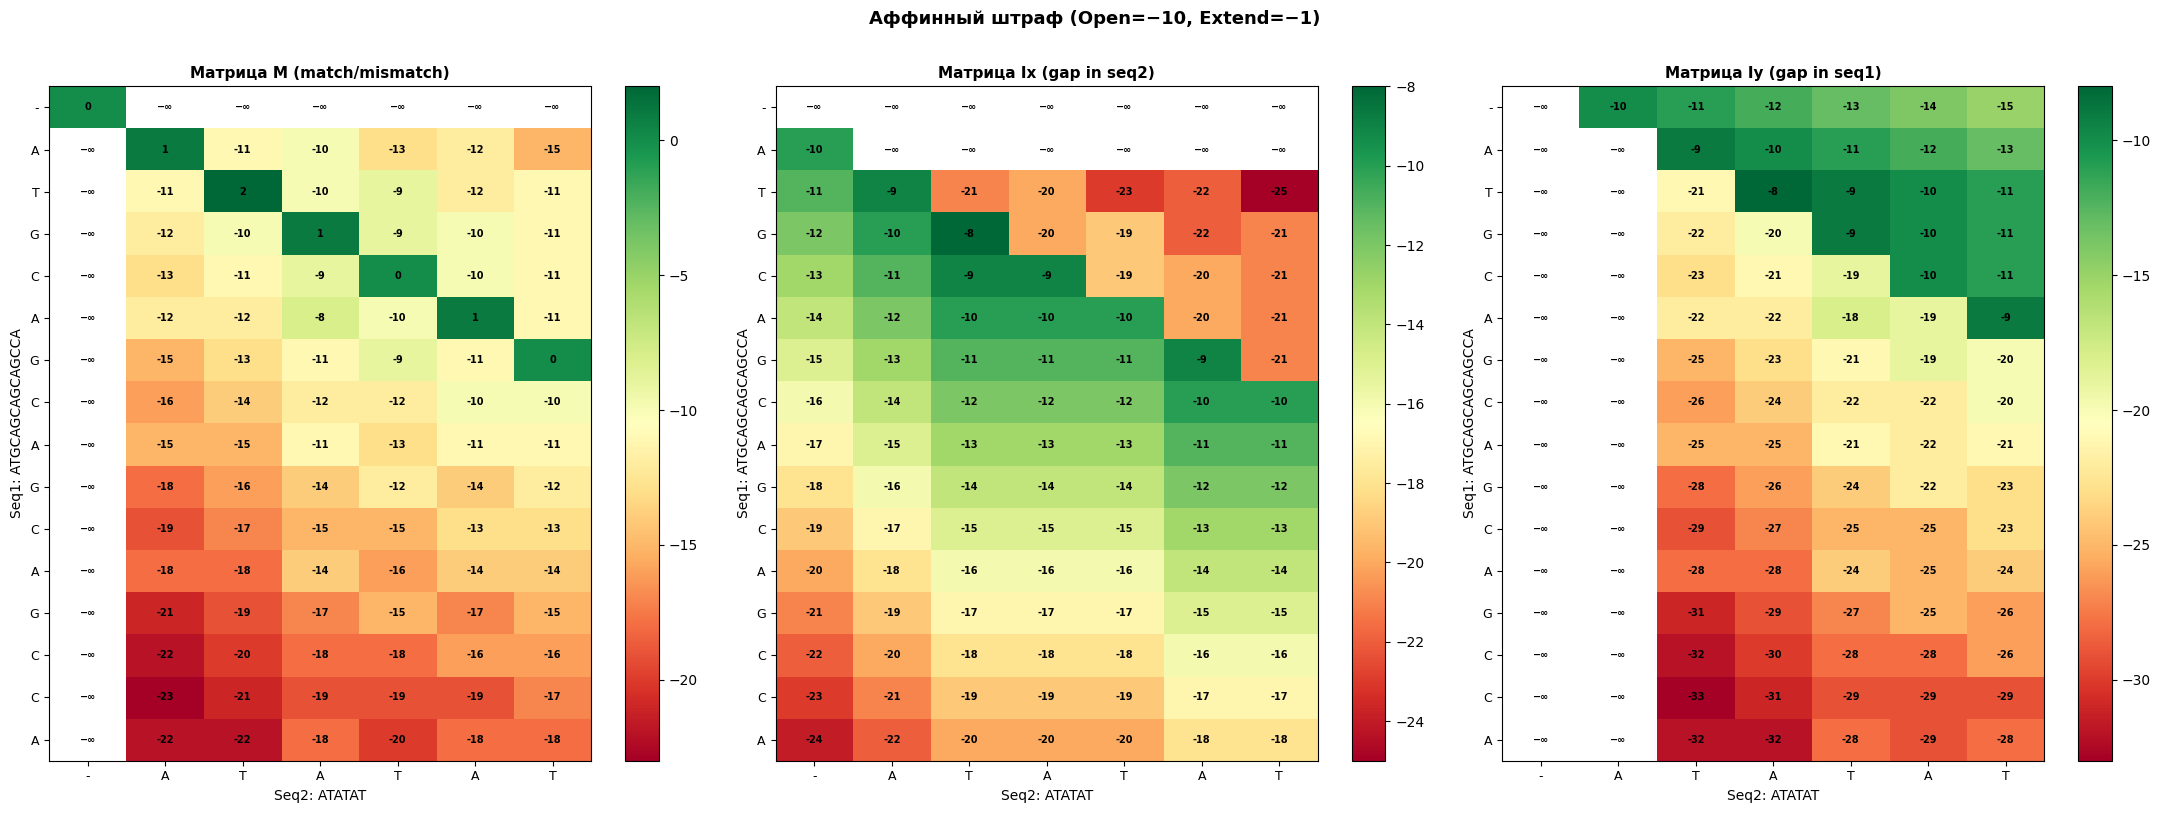

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
matrices = [M_aff, Ix_aff, Iy_aff]
names    = ['M (match/mismatch)', 'Ix (gap in seq2)', 'Iy (gap in seq1)']

for ax, mat, name in zip(axes, matrices, names):
    display = np.where(mat < -1000, np.nan, mat)
    im = ax.imshow(display, cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax)
    
    ax.set_xticks(range(len(seq2)+1))
    ax.set_xticklabels(['-'] + list(seq2), fontsize=9)
    ax.set_yticks(range(len(seq1)+1))
    ax.set_yticklabels(['-'] + list(seq1), fontsize=9)
    
    for i in range(len(seq1)+1):
        for j in range(len(seq2)+1):
            val = mat[i][j]
            txt = '−∞' if val < -1000 else str(int(val))
            ax.text(j, i, txt, ha='center', va='center', fontsize=7, fontweight='bold')
    
    ax.set_title(f'Матрица {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Seq2: ' + seq2)
    ax.set_ylabel('Seq1: ' + seq1)

plt.suptitle('Аффинный штраф (Open=−10, Extend=−1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



